In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
with open('Pickled Objects/preprocessed_data.pkl', 'rb') as file:
    data = pickle.load(file)

data.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,...,Airbags,Gear box type_Automatic,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_4x4,Drive wheels_Front,Drive wheels_Rear,Wheel_Left wheel,Wheel_Right-hand drive
0,13328,1399.0,32.0,1242.0,2010,4.0,1.0,2.0,3.5,186005.0,...,12,1.0,0,0,0,0,0.0,0,1,0
1,16621,1018.0,8.0,658.0,2011,4.0,0.0,5.0,3.0,192000.0,...,8,0.0,0,0,0,0,0.0,0,1,0
2,8467,0.0,21.0,684.0,2006,3.0,0.0,5.0,1.3,200000.0,...,2,0.0,0,0,0,0,1.0,0,1,0
3,3607,862.0,16.0,661.0,2011,4.0,1.0,2.0,2.5,168966.0,...,0,1.0,0,0,0,0,0.0,0,1,0
4,11726,446.0,21.0,684.0,2014,3.0,1.0,5.0,1.3,91901.0,...,4,1.0,0,0,0,0,1.0,0,1,0


### ***Polynomial Regression***

In [3]:
X = data.drop(columns=['Price'], axis = 1)
y = data['Price']

In [4]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Standardizing the feature
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Transform the feature to polynomial features (degree 3 for example)
poly = PolynomialFeatures(degree=3)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [7]:
# Create and train the Polynomial Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
# Make predictions
y_pred = model.predict(X_test)

In [9]:
# Evaluate the Polynomial Regression model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Polynomial Regression - MSE: {mse}, R2: {r2}")

Polynomial Regression - MSE: 69589672.95270807, R2: 0.6171846481513268


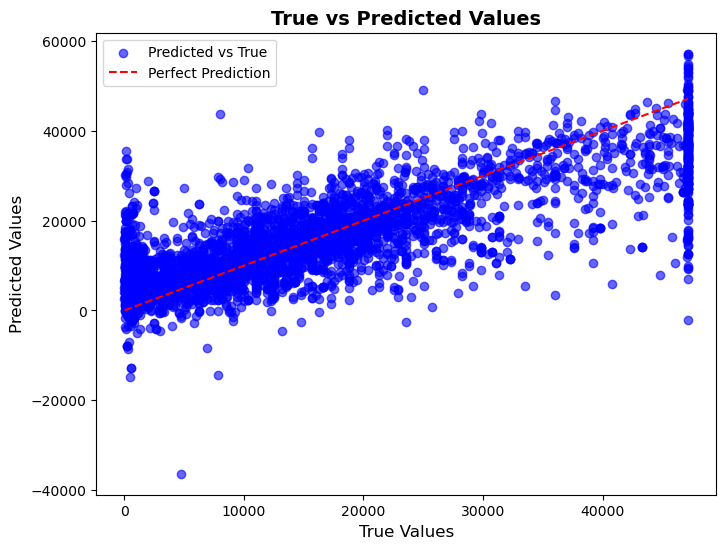

In [10]:
# Plot true vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs True')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('True Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('True vs Predicted Values', fontsize=14, fontweight='bold')
plt.legend()
plt.show()